In [1]:
%load_ext autoreload
%autoreload 2

In [24]:
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

import dafm.plots

sns.set_theme(style='ticks', font_scale=2.0, palette=sns.color_palette())

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
attach '../optuna.sqlite';
use runs;
""")

# Data selection (Lorenz 96, KS 1024, NS 256)

In [53]:
da_setting_rows = duckdb.sql("""
select * from (
    select 'L96' as setting_name, DataAssimilationSetting, rng_seed
    from setting_lorenz96bao2024_identity_obs
    union
    select 'KS' as setting_name, DataAssimilationSetting, rng_seed
    from setting_kuramotosivashinsky_identity_obs
    where dimension = 1024
    union
    select 'NS' as setting_name, DataAssimilationSetting, rng_seed
    from setting_navierstokesdim256_identity_obs
)
where rng_seed = 2376999025
""")
da_setting_rows

┌──────────────┬─────────────────────────┬────────────┐
│ setting_name │ DataAssimilationSetting │  rng_seed  │
│   varchar    │          int64          │   int64    │
├──────────────┼─────────────────────────┼────────────┤
│ L96          │                     205 │ 2376999025 │
│ KS           │                      47 │ 2376999025 │
│ NS           │                      46 │ 2376999025 │
└──────────────┴─────────────────────────┴────────────┘

In [64]:
da_setting_rows = duckdb.sql("""
select * from (
    select 'L96' as setting_name, DataAssimilationSetting, rng_seed
    from setting_lorenz96bao2024_atan_obs
    union
    select 'KS' as setting_name, DataAssimilationSetting, rng_seed
    from setting_kuramotosivashinsky_atan_obs
    where dimension = 1024
    union
    select 'NS' as setting_name, DataAssimilationSetting, rng_seed
    from setting_navierstokesdim256_atan_obs
)
where rng_seed = 2376999025
""")
da_setting_rows

┌──────────────┬─────────────────────────┬────────────┐
│ setting_name │ DataAssimilationSetting │  rng_seed  │
│   varchar    │          int64          │   int64    │
├──────────────┼─────────────────────────┼────────────┤
│ KS           │                      10 │ 2376999025 │
│ L96          │                      56 │ 2376999025 │
│ NS           │                      12 │ 2376999025 │
└──────────────┴─────────────────────────┴────────────┘

In [65]:
filters = duckdb.sql("""
select
    Filter,
    filter_name,
    sampling_time_step_count
from to_plot_generative_filter
where filter_name in ('EnFF-OT', 'EnFF-F2P')
""")
filters

┌────────┬─────────────┬──────────────────────────┐
│ Filter │ filter_name │ sampling_time_step_count │
│ int64  │   varchar   │          int64           │
├────────┼─────────────┼──────────────────────────┤
│     17 │ EnFF-F2P    │                       10 │
│     73 │ EnFF-F2P    │                       10 │
│    107 │ EnFF-F2P    │                       10 │
│    130 │ EnFF-F2P    │                       10 │
│    186 │ EnFF-F2P    │                       10 │
│    219 │ EnFF-F2P    │                       10 │
│    226 │ EnFF-F2P    │                       10 │
│    230 │ EnFF-F2P    │                       10 │
│    240 │ EnFF-F2P    │                       10 │
│    275 │ EnFF-F2P    │                       10 │
│     ·  │    ·        │                        · │
│     ·  │    ·        │                        · │
│     ·  │    ·        │                        · │
│   9728 │ EnFF-OT     │                        5 │
│   9754 │ EnFF-OT     │                       10 │
│   9758 │ E

# Build Optuna trial rows

In [66]:
optuna_trials = duckdb.sql("""
select
    OptunaStudy.alt_id as study_alt_id,
    Conf.DataAssimilationSetting,
    da_setting_rows.setting_name,
    filters.filter_name,
    filters.sampling_time_step_count,
    trials.trial_id,
    cast(trials.trial_id as varchar) as trial_alt_id,
    trial_values.value as rmse,
    max(case when trial_params.param_name like '%sigma_min' then trial_params.param_value end) as sigma_min,
    max(case when trial_params.param_name in ('lambda', 'filter.guidance.schedule.constant') then trial_params.param_value end) as lambda
from OptunaStudy
join Conf on OptunaStudy.BaseConf = Conf.id
join da_setting_rows on Conf.DataAssimilationSetting = da_setting_rows.DataAssimilationSetting
join filters on Conf.Filter = filters.Filter
join optuna.studies as studies on OptunaStudy.alt_id = studies.study_name
join optuna.trials as trials on studies.study_id = trials.study_id
join optuna.trial_values as trial_values on trials.trial_id = trial_values.trial_id
join optuna.trial_params as trial_params on trials.trial_id = trial_params.trial_id
group by
    OptunaStudy.alt_id,
    Conf.DataAssimilationSetting,
    da_setting_rows.setting_name,
    filters.filter_name,
    filters.sampling_time_step_count,
    trials.trial_id,
    cast(trials.trial_id as varchar),
    trial_values.value
having sigma_min is not null and lambda is not null
""")
optuna_trials

┌──────────────┬─────────────────────────┬──────────────┬─────────────┬──────────────────────────┬──────────┬──────────────┬──────────────────────┬────────────────────────┬───────────────────────┐
│ study_alt_id │ DataAssimilationSetting │ setting_name │ filter_name │ sampling_time_step_count │ trial_id │ trial_alt_id │         rmse         │       sigma_min        │        lambda         │
│   varchar    │          int64          │   varchar    │   varchar   │          int64           │  int64   │   varchar    │        double        │         double         │        double         │
├──────────────┼─────────────────────────┼──────────────┼─────────────┼──────────────────────────┼──────────┼──────────────┼──────────────────────┼────────────────────────┼───────────────────────┤
│ 6zwinrkj     │                      10 │ KS           │ EnFF-F2P    │                       10 │     1043 │ 1043         │  0.05115326501429081 │   0.006032600038879064 │  0.007397627227804577 │
│ uqjcfp8d     

In [67]:
coverage_plot2 = duckdb.sql("""
select
    setting_name,
    filter_name,
    count(*) as trial_count,
    count(distinct sigma_min) as unique_sigma_min,
    count(distinct lambda) as unique_lambda
from optuna_trials
where sampling_time_step_count = 5
group by setting_name, filter_name
order by setting_name, filter_name
""")
coverage_plot2

┌──────────────┬─────────────┬─────────────┬──────────────────┬───────────────┐
│ setting_name │ filter_name │ trial_count │ unique_sigma_min │ unique_lambda │
│   varchar    │   varchar   │    int64    │      int64       │     int64     │
├──────────────┼─────────────┼─────────────┼──────────────────┼───────────────┤
│ KS           │ EnFF-F2P    │          42 │               42 │            42 │
│ KS           │ EnFF-OT     │          44 │               44 │            44 │
│ L96          │ EnFF-F2P    │          49 │               49 │            49 │
│ L96          │ EnFF-OT     │          49 │               49 │            49 │
│ NS           │ EnFF-F2P    │          42 │               42 │            42 │
│ NS           │ EnFF-OT     │          45 │               45 │            45 │
└──────────────┴─────────────┴─────────────┴──────────────────┴───────────────┘

# Plot 1: optimal sigma_min and lambda vs sampling time steps

In [68]:
best_trials = duckdb.sql(r"""
with ranked as (
    select
        *,
        dense_rank() over (
            partition by setting_name, filter_name, sampling_time_step_count
            order by rmse asc, trial_id asc
        ) as rnk
    from optuna_trials
)
select
    setting_name,
    filter_name,
    sampling_time_step_count,
    sigma_min,
    lambda
from ranked
where rnk = 1
order by setting_name, filter_name, sampling_time_step_count
""")
best_trials

┌──────────────┬─────────────┬──────────────────────────┬────────────────────────┬───────────────────────┐
│ setting_name │ filter_name │ sampling_time_step_count │       sigma_min        │        lambda         │
│   varchar    │   varchar   │          int64           │         double         │        double         │
├──────────────┼─────────────┼──────────────────────────┼────────────────────────┼───────────────────────┤
│ KS           │ EnFF-F2P    │                        5 │   0.005263515825015734 │  0.006935310286542734 │
│ KS           │ EnFF-F2P    │                       10 │   0.006032600038879064 │  0.007397627227804577 │
│ KS           │ EnFF-F2P    │                       20 │    0.01789058880575956 │  0.007605787399507009 │
│ KS           │ EnFF-F2P    │                       50 │     0.0122441178260851 │  0.008164740559181925 │
│ KS           │ EnFF-F2P    │                      100 │   0.002030149291535136 │  0.007171534526725351 │
│ KS           │ EnFF-OT     │       

In [69]:
plot1_df = duckdb.sql(r"""
unpivot (
    select
        setting_name,
        filter_name,
        sampling_time_step_count,
        sigma_min,
        lambda
    from best_trials
)
on sigma_min, lambda
into name hyperparameter value value
""").pl()
plot1_df

setting_name,filter_name,sampling_time_step_count,hyperparameter,value
str,str,i64,str,f64
"""KS""","""EnFF-F2P""",5,"""sigma_min""",0.005264
"""KS""","""EnFF-F2P""",5,"""lambda""",0.006935
"""KS""","""EnFF-F2P""",10,"""sigma_min""",0.006033
"""KS""","""EnFF-F2P""",10,"""lambda""",0.007398
"""KS""","""EnFF-F2P""",20,"""sigma_min""",0.017891
…,…,…,…,…
"""NS""","""EnFF-OT""",20,"""lambda""",0.018362
"""NS""","""EnFF-OT""",50,"""sigma_min""",0.004302
"""NS""","""EnFF-OT""",50,"""lambda""",0.017643


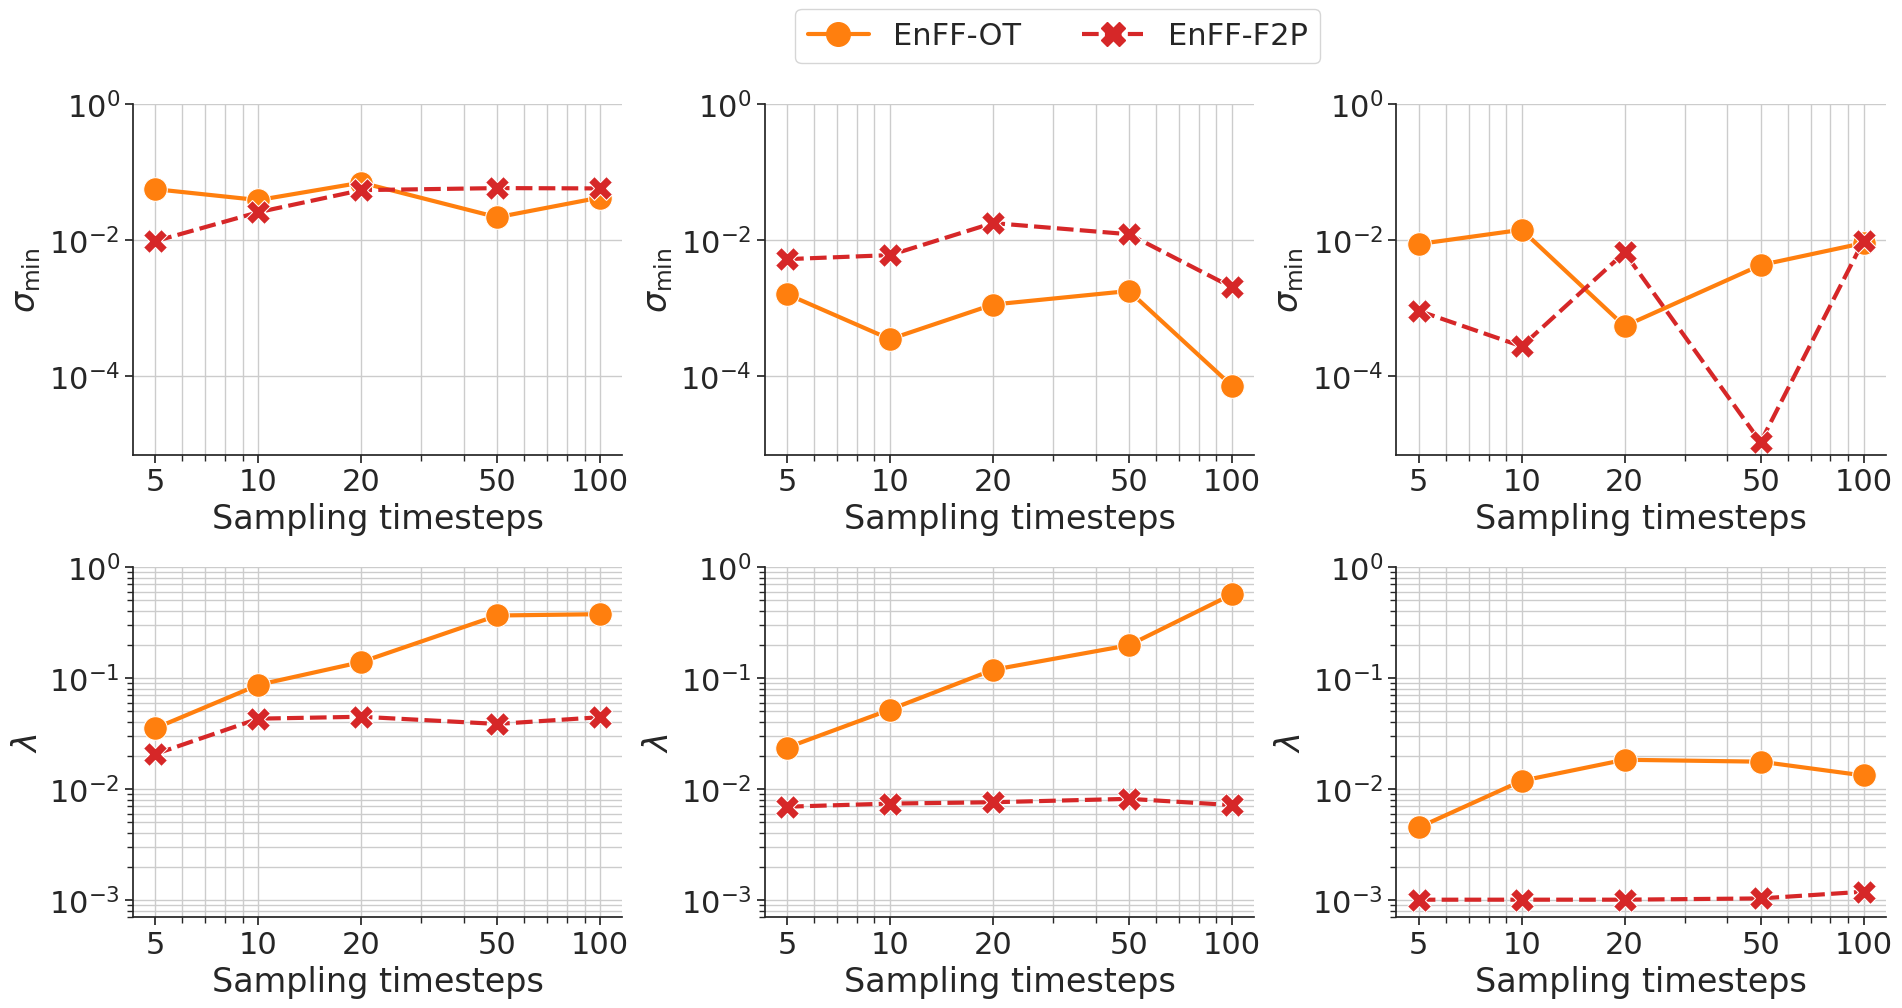

In [107]:
order = [k for k, _ in sorted(dafm.plots.FILTER_ORDER.items(), key=lambda x: x[1]) if k in ('EnFF-OT', 'EnFF-F2P')]
plot1 = (
    sns.relplot(
        kind='line',
        data=plot1_df.to_pandas(),
        x='sampling_time_step_count',
        y='value',
        hue='filter_name',
        style='filter_name',
        row='hyperparameter',
        col='setting_name',
        row_order=['sigma_min', 'lambda'],
        col_order=['L96', 'KS', 'NS'],
        hue_order=order,
        style_order=order,
        palette=dafm.plots.FILTER_PALETTE,
        markers=True,
        # linewidth=3,
        # markersize=11,
        # aspect=1.2,
        linewidth=3,
        markersize=17,
        aspect=1.3,
        facet_kws=dict(sharex=False, sharey=False),
    )
    # .set_titles('{col_name}')
    .set_titles('')
    .set(
        xscale='log', yscale='log', xlabel='Sampling timesteps',
        xticks=plot1_df['sampling_time_step_count'].unique(),
        xticklabels=plot1_df['sampling_time_step_count'].unique(),
    )
)
for (row, col, hue), _ in plot1.facet_data():
    ax = plot1.axes[row, col]
    name = plot1.row_names[row]
    ax.grid(which='minor')
    if name == 'sigma_min':
        ax.set_ylabel(r'$\sigma_{\min}$')
        ax.set_ylim(7e-6, 1)
    elif name == 'lambda':
        ax.set_ylabel(r'$\lambda$')
        ax.set_ylim(7e-4, 1)
    ax.grid()
# sns.move_legend(plot1, loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=2, title='')
sns.move_legend(
    plot1,
    loc='upper center',
    ncol=2,
    title='',
    bbox_to_anchor=(0.5, 1.04),
    frameon=True,
    fancybox=True,
)

In [108]:
dafm.plots.save_all_subfigures(plot1, 'HyperparameterLine')

# Plot 2: RMSE vs sigma_min and lambda (fixed sampling_time_step_count = 5)

In [71]:
plot2_df = duckdb.sql(r"""
select
    setting_name,
    filter_name,
    sigma_min,
    lambda,
    avg(rmse) as rmse_mean,
    count(*) as n_trials
from optuna_trials
where sampling_time_step_count = 5
group by setting_name, filter_name, sigma_min, lambda
order by setting_name, filter_name, sigma_min, lambda
""").pl()
plot2_df

setting_name,filter_name,sigma_min,lambda,rmse_mean,n_trials
str,str,f64,f64,f64,i64
"""KS""","""EnFF-F2P""",0.000011,0.001612,1.016354,1
"""KS""","""EnFF-F2P""",0.000011,0.003857,0.082198,1
"""KS""","""EnFF-F2P""",0.000013,0.013689,0.066471,1
"""KS""","""EnFF-F2P""",0.000016,0.037211,0.109555,1
"""KS""","""EnFF-F2P""",0.000018,0.020309,0.082051,1
…,…,…,…,…,…
"""NS""","""EnFF-OT""",0.064655,0.015099,0.048496,1
"""NS""","""EnFF-OT""",0.088413,0.177243,0.156769,1
"""NS""","""EnFF-OT""",0.225025,0.024232,0.100946,1


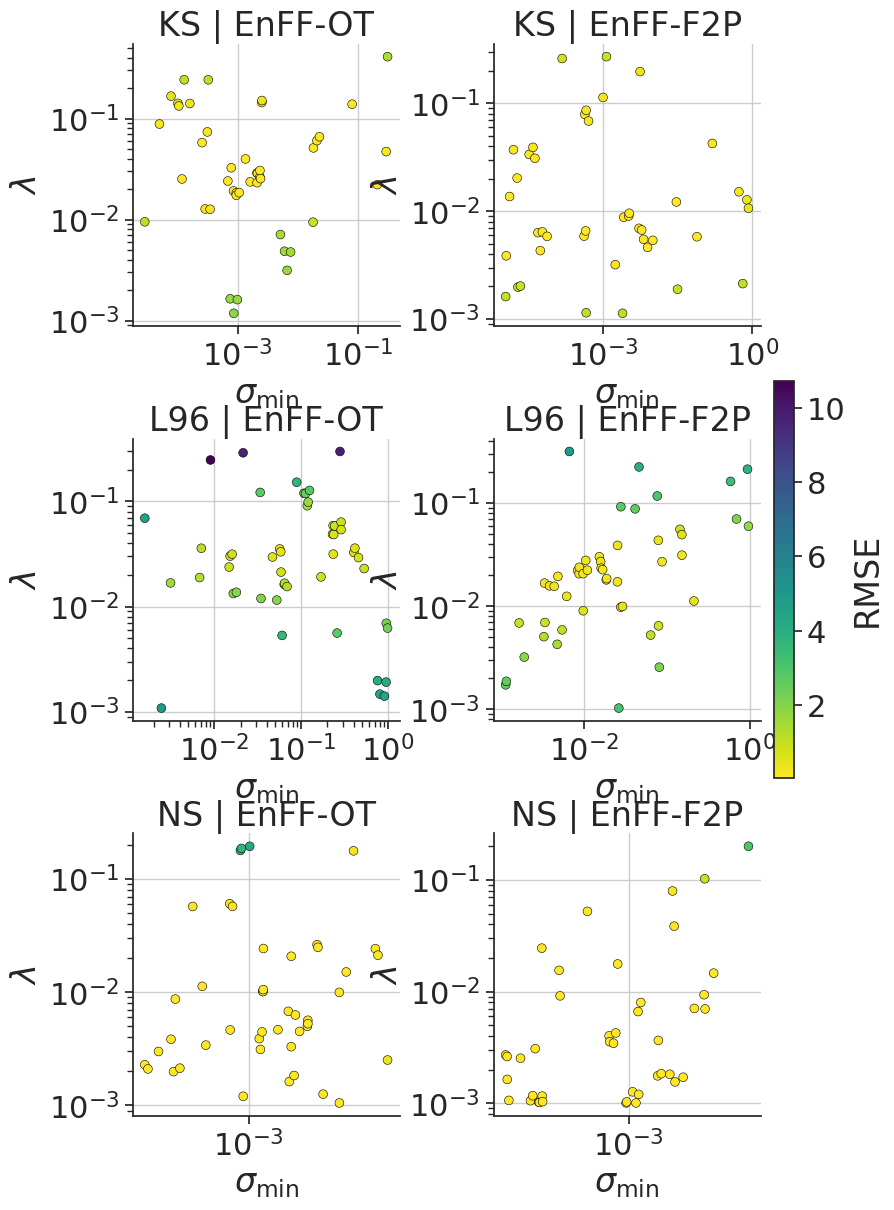

In [72]:
plot2_pd = plot2_df.to_pandas()
norm = plt.Normalize(plot2_pd['rmse_mean'].min(), plot2_pd['rmse_mean'].max())
g = sns.FacetGrid(
    plot2_pd,
    row='setting_name',
    col='filter_name',
    row_order=sorted(plot2_pd['setting_name'].unique()),
    col_order=order,
    sharex=False,
    sharey=False,
    height=4.2,
    aspect=1.0,
)
g.map_dataframe(
    sns.scatterplot,
    x='sigma_min',
    y='lambda',
    size='n_trials',
    hue='rmse_mean',
    hue_norm=norm,
    palette='viridis_r',
    sizes=(40, 220),
    edgecolor='black',
    linewidth=0.4,
    legend=False,
)
g.set(xscale='log', yscale='log', xlabel=r'$\sigma_{\min}$', ylabel=r'$\lambda$')
g.set_titles('{row_name} | {col_name}')
for ax in g.axes.flatten():
    ax.grid()
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])
cbar = g.figure.colorbar(sm, ax=g.axes, fraction=0.03, pad=0.02)
cbar.set_label('RMSE')

# Plot 2b: RMSE filled contour (sampled grid, sampling_time_step_count = 5)

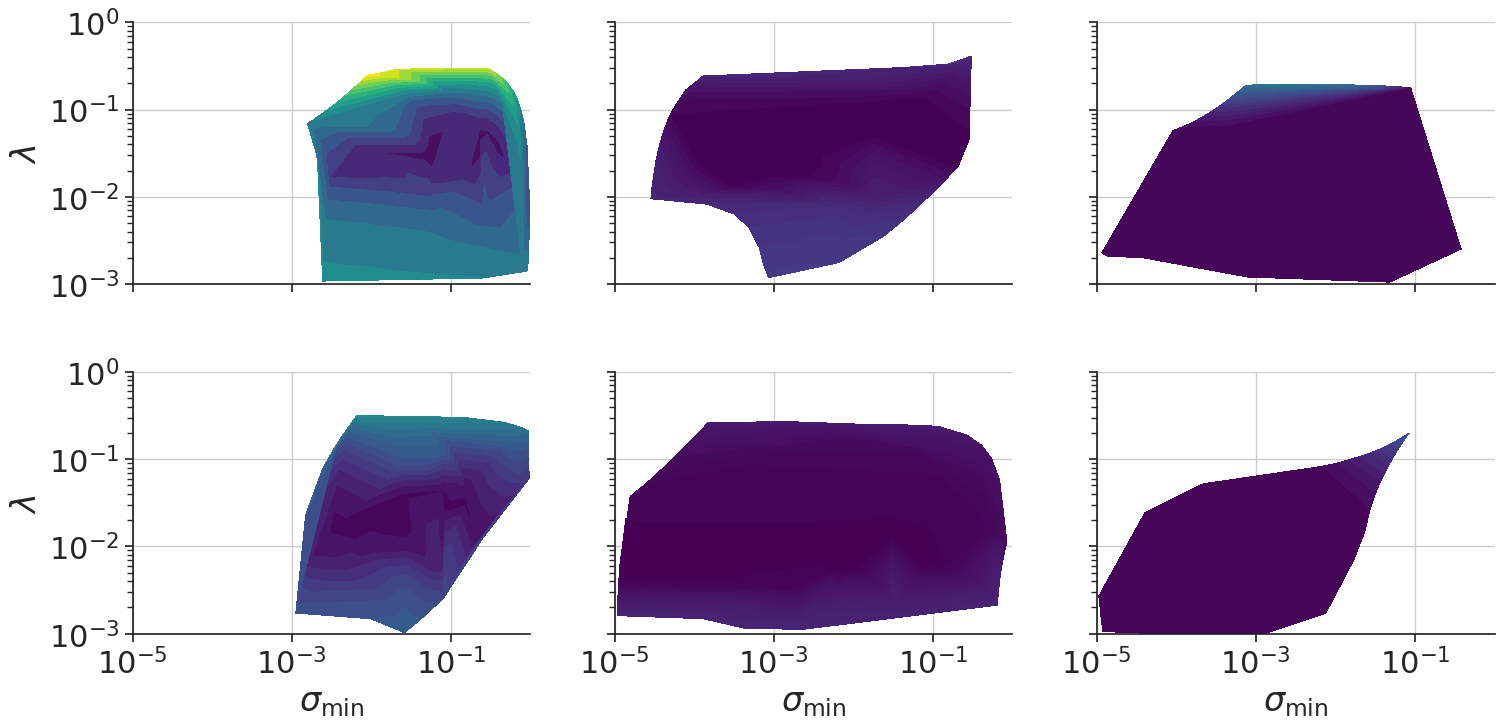

In [85]:
plot2_contour_pd = plot2_df.to_pandas()
setting_order = ['L96', 'KS', 'NS']
filter_order = [f for f in order if f in plot2_contour_pd['filter_name'].unique()]

contour_vmin = plot2_contour_pd['rmse_mean'].min()
contour_vmax = plot2_contour_pd['rmse_mean'].max()
contour_levels = 14
contour_cmap = 'viridis'

plot2_contour_grid = sns.FacetGrid(
    data=plot2_contour_pd,
    col='setting_name',
    row='filter_name',
    row_order=filter_order,
    col_order=setting_order,
    # sharex=False,
    # sharey=False,
    height=3.8,
    aspect=1.35,
)

contour_mappable = None
for (row, col, hue), data in plot2_contour_grid.facet_data():
    ax = plot2_contour_grid.axes[row, col]
    if data.empty:
        continue

    x_vals = data['sigma_min'].to_numpy()
    y_vals = data['lambda'].to_numpy()
    z_vals = data['rmse_mean'].to_numpy()

    contour_mappable = ax.tricontourf(
        x_vals,
        y_vals,
        z_vals,
        levels=contour_levels,
        vmin=contour_vmin,
        vmax=contour_vmax,
        cmap=contour_cmap,
    )

    ax.set_xlim(1e-5, 1)
    ax.set_ylim(1e-3, 1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\sigma_{\min}$')
    ax.set_ylabel(r'$\lambda$')
    ax.grid()

# plot2_contour_grid.set_titles('{row_name} | {col_name}')
plot2_contour_grid.set_titles('')
# plt.tight_layout()

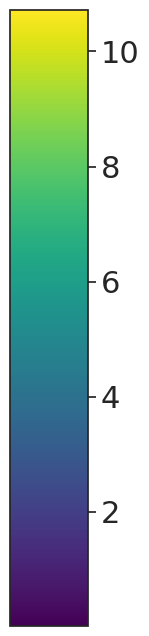

In [89]:
fig, ax = plt.subplots(figsize=(1, 8))
contour_norm = plt.Normalize(vmin=contour_vmin, vmax=contour_vmax)
fig.colorbar(
    plt.cm.ScalarMappable(norm=contour_norm, cmap=contour_cmap),
    cax=ax,
    location='right',
)
# ax.set_ylabel('RMSE')
fig.savefig(f'HyperparameterContour.colorbar.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)

In [87]:
dafm.plots.save_all_subfigures(plot2_contour_grid, 'HyperparameterContour')